In [1]:
# Cell 1 -- Imports and load the trained model
# We load the model we already trained and saved in Step 5, rather than
# retraining -- this notebook is purely for INSPECTING an existing model.
import sys, os
sys.path.append(os.path.abspath("../src"))

import tensorflow as tf
from visualize import get_conv_layer_names, visualize_filters

model = tf.keras.models.load_model("../models/baseline_cnn.keras")
model.summary()

Model: "Interpretable_Fashion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,104 (74.63 KB)

 Trainable params: 6,330 (24.73 KB)

 Non-trainable params: 112 (448.00 B)

 Optimizer params: 12,662 (49.46 KB)

In [2]:
# Cell 2 -- List the conv layers we can inspect
conv_layers = get_conv_layer_names(model)
print("Conv2D layers found:", conv_layers)

Conv2D layers found: ['conv2d', 'conv2d_1', 'conv2d_2']


Layer 'conv2d': 8 filters, each 3x3, operating over 1 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer1.png


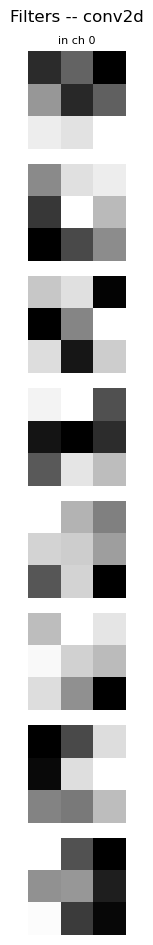

In [3]:
# Cell 3 -- Visualize Layer 1's filters (the directly-interpretable ones)
visualize_filters(model, conv_layers[0], save_path="../reports/figures/filters_layer1.png")

Layer 'conv2d_1': 16 filters, each 3x3, operating over 8 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer2.png


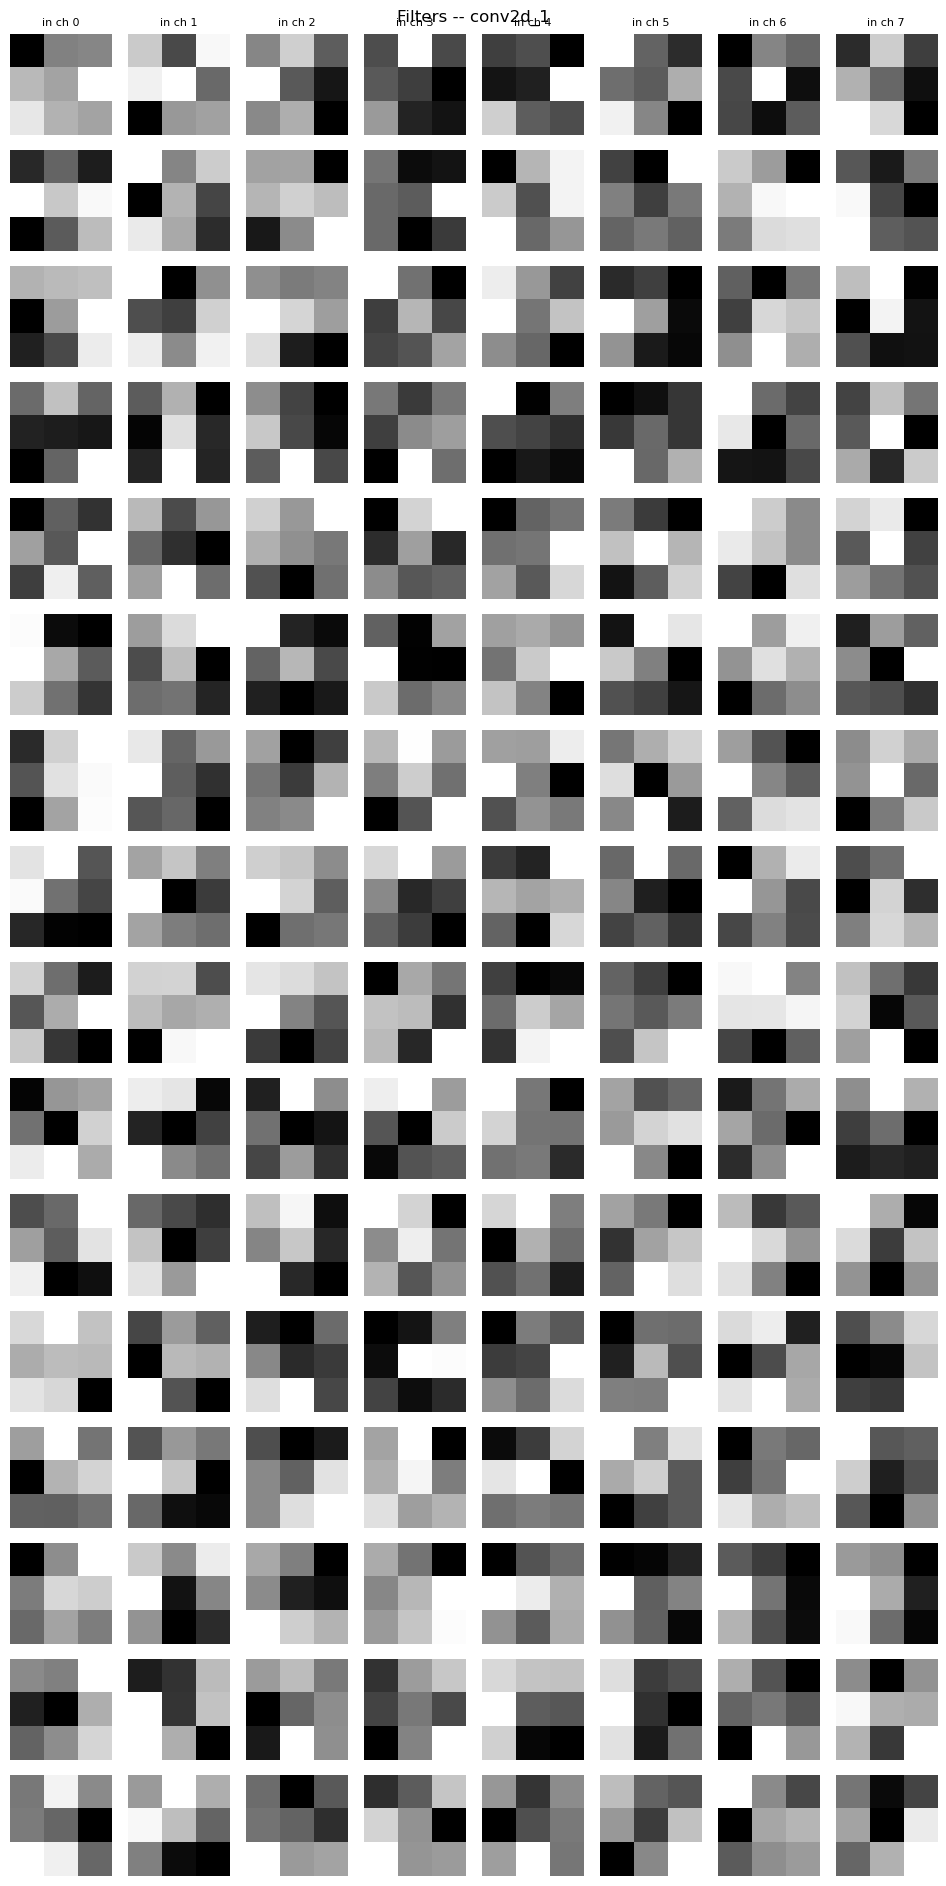

In [4]:
# Cell 4 -- Visualize Layer 2's filters
# Notice this grid is much wider now -- one column per input channel,
# demonstrating that each filter here combines all 8 of layer 1's outputs.
visualize_filters(model, conv_layers[1], save_path="../reports/figures/filters_layer2.png")

Layer 'conv2d_2': 32 filters, each 3x3, operating over 16 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer3.png


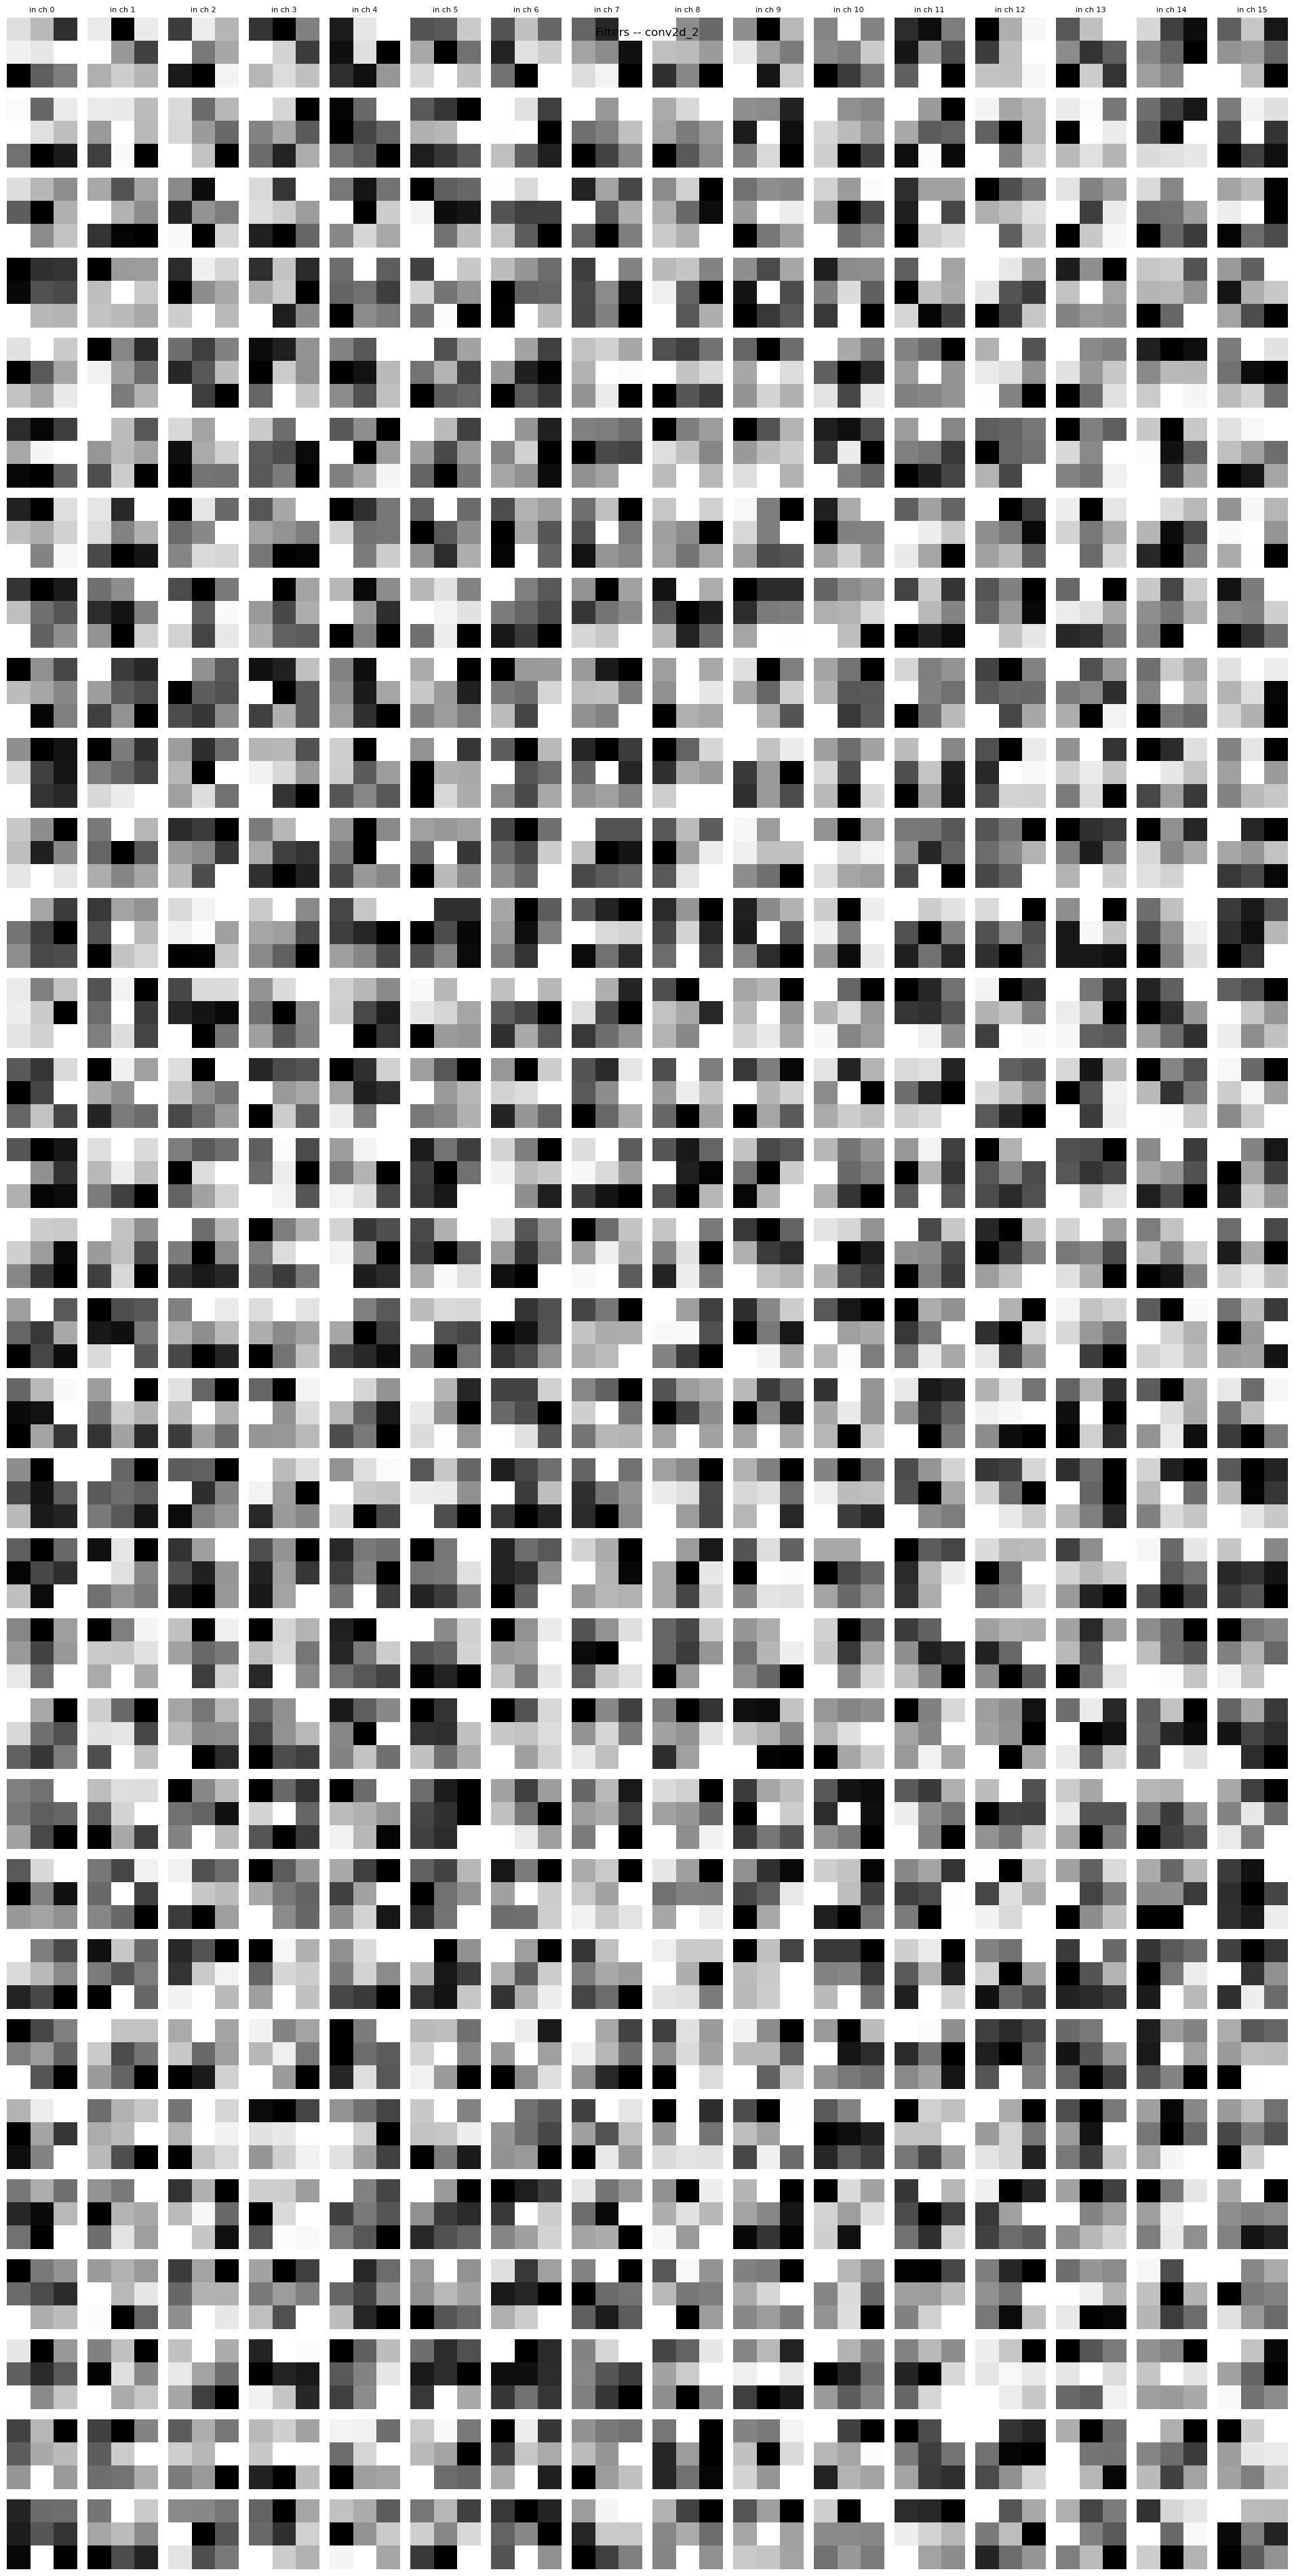

In [5]:
# Cell 5 -- Visualize Layer 3's filters
visualize_filters(model, conv_layers[2], save_path="../reports/figures/filters_layer3.png")